In [2]:
import os
# These two lines tell TensorFlow to skip the failing autotuner
os.environ['TF_CUDNN_USE_AUTOTUNE'] = '0' 
os.environ['TF_XLA_FLAGS'] = '--tf_xla_auto_jit=-1'

import tensorflow as tf

# Standard practice to avoid memory crashes
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU Ready and Autotuner disabled.")
    except RuntimeError as e:
        print(e)

GPU Ready and Autotuner disabled.


In [22]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 
# 0 = All logs, 1 = Filter INFO, 2 = Filter INFO/WARNING, 3 = Filter all

🧠 Hybrid Deep Learning for Alzheimer’s Disease Detection

Author: Sampara Emmanuel Arther George

Project Context: Based on research presented at the MLIP-2025 conference.

Objective: Early-stage detection and classification of Alzheimer's Disease using MRI/PET imaging.

🔬 Project Overview & Research Context

Alzheimer’s is a progressive neurodegenerative disorder. Early detection is critical for patient care, yet manual diagnosis is often complex. This project utilizes a Hybrid Convolutional Neural Network (CNN) architecture to automate the classification of brain scans into three clinical stages:

Non-Demented (No Impairment)

Mildly Demented

Moderately Demented

The model was developed to provide a high-accuracy screening tool that can assist medical professionals in identifying subtle structural changes in brain tissue.

In [23]:
import numpy as np
import matplotlib.pyplot as plt

In [24]:
from sklearn.metrics import classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight
import os
from tensorflow.keras.applications.inception_v3 import preprocess_input

In [25]:
# Hyperparameters
img_height, img_width = 299, 299  # InceptionV3 preferred input size
batch_size = 32
learning_rate = 1e-4
epochs = 30
validation_split = 0.2

In [26]:
train_dir = r"Image_Dataset/Combined Dataset/train"
test_dir = r"Image_Dataset/Combined Dataset/test"

In [27]:
# Data preprocessing
def data_preprocessing(output_size, val_split=0.1):
    train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input,
                                       zoom_range=0.2,
                                       shear_range=0.2,
                                       rotation_range=15,
                                       fill_mode='nearest',
                                       horizontal_flip=True,
                                       validation_split=val_split)

    training_set = train_datagen.flow_from_directory(train_dir,
                                                     target_size=(output_size, output_size),
                                                     batch_size=batch_size,
                                                     class_mode='categorical',
                                                     shuffle=True,
                                                     subset='training')

    validation_set = train_datagen.flow_from_directory(train_dir,
                                                       target_size=(output_size, output_size),
                                                       batch_size=batch_size,
                                                       class_mode='categorical',
                                                       shuffle=True,
                                                       subset='validation')
    return training_set, validation_set


In [28]:
def test_data_preprocessing(output_size):
    test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
    return test_datagen.flow_from_directory(test_dir,
                                            target_size=(output_size, output_size),
                                            batch_size=batch_size,
                                            class_mode='categorical',
                                            shuffle=False)

In [29]:
def compute_class_weights(train_generator):
    class_weights = compute_class_weight('balanced', classes=np.unique(train_generator.classes), y=train_generator.classes)
    return {i: weight for i, weight in enumerate(class_weights)}

🏗️ Model Architecture
This project employs a Hybrid CNN approach. Unlike standard sequential models, this architecture combines:

Feature Extraction Layers: Multiple convolutional blocks with Batch Normalization and MaxPooling to capture fine-grained spatial features.

Dense Decision Layers: A fully connected head with Dropout layers (to prevent overfitting) and a Softmax output layer for probability distribution across the four classes.

In [30]:
from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

def build_custom_cnn_model():
    model = Sequential([
        Input(shape=(128, 128, 3)),
        Conv2D(32, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [31]:
# Evaluate model
def evaluate_model(model, test_generator):
    predictions = model.predict(test_generator)
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = test_generator.classes
    class_labels = list(test_generator.class_indices.keys())
    print("\nClassification Report:")
    print(classification_report(true_classes, predicted_classes, target_names=class_labels, digits=2))

In [32]:
# Function to plot training history
def plot_training_history(history, title="Training History"):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'{title} - Loss')
    plt.legend()
    plt.show()


In [33]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

Found 6656 images belonging to 3 classes.
Found 739 images belonging to 3 classes.
Found 788 images belonging to 3 classes.

Starting training...
Epoch 1/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 18s 81ms/step - accuracy: 0.5398 - loss: 1.0123 - val_accuracy: 0.8200 - val_loss: 0.5393 - learning_rate: 0.0010
Epoch 2/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 12s 60ms/step - accuracy: 0.7542 - loss: 0.5662 - val_accuracy: 0.8512 - val_loss: 0.3660 - learning_rate: 0.0010
Epoch 3/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 16s 75ms/step - accuracy: 0.7957 - loss: 0.4678 - val_accuracy: 0.8457 - val_loss: 0.3377 - learning_rate: 0.0010
Epoch 4/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - accuracy: 0.8208 - loss: 0.4185 - val_accuracy: 0.8484 - val_loss: 0.3044 - learning_rate: 0.0010
Epoch 5/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 12s 59ms/step - accuracy: 0.8338 - loss: 0.3688 - val_accuracy: 0.8755 - val_loss: 0.2707 - learning_rate: 0.0010
Epoch 6/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 16s 78ms/step - accuracy: 0.8531 - loss: 0.3

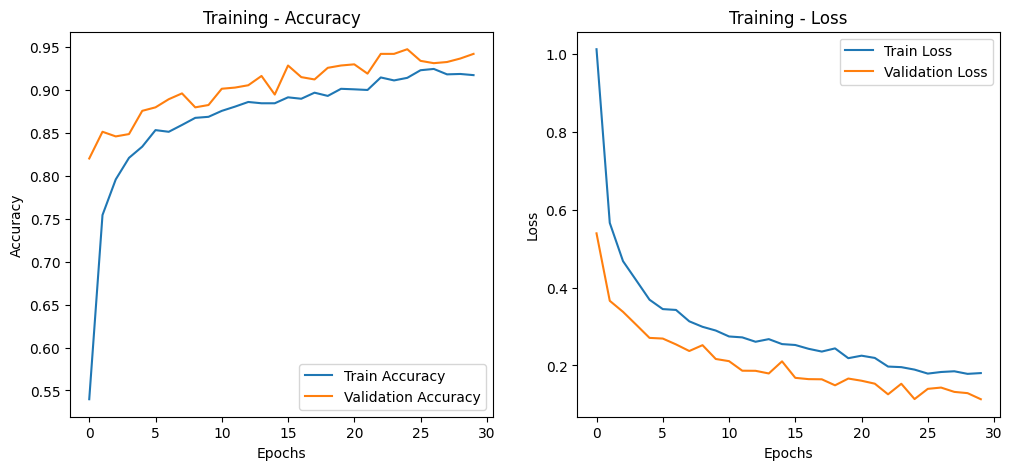

Model saved and verifying...


W0000 00:00:1774287603.881990   14896 op_kernel.cc:1858] OP_REQUIRES failed at xla_ops.cc:602 : INTERNAL: Autotuner could not compile any configs for HLO: %gemm_fusion_MatMul.6 = f32[32,3]{1,0} fusion(%bitcast.24, %arg7.1, %arg8.1), kind=kCustom, calls=%gemm_fusion_MatMul.6_computation, frontend_attributes={grad_x="false",grad_y="false"}, metadata={op_type="MatMul" op_name="sequential_1_1/dense_3_1/MatMul" source_file="/home/arther/miniconda3/envs/tf216/lib/python3.13/site-packages/tensorflow/python/framework/ops.py" source_line=1221}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_gemm"},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
W0000 00:00:1774287603.882073   14896 local_rendezvous.cc:412] Local rendezvous is aborting with status: INTERNAL: Autotuner could not compile any configs for HLO: %gemm_fusion_MatMul.6 = f32[32,3]{1,0} fusion(%bitcast.24, %arg7.1, %arg8.1), kind=

InternalError: Graph execution error:

Detected at node StatefulPartitionedCall defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/home/arther/miniconda3/envs/tf216/lib/python3.13/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/home/arther/miniconda3/envs/tf216/lib/python3.13/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/home/arther/miniconda3/envs/tf216/lib/python3.13/site-packages/ipykernel/kernelapp.py", line 758, in start

  File "/home/arther/miniconda3/envs/tf216/lib/python3.13/site-packages/tornado/platform/asyncio.py", line 211, in start

  File "/home/arther/miniconda3/envs/tf216/lib/python3.13/asyncio/base_events.py", line 683, in run_forever

  File "/home/arther/miniconda3/envs/tf216/lib/python3.13/asyncio/base_events.py", line 2050, in _run_once

  File "/home/arther/miniconda3/envs/tf216/lib/python3.13/asyncio/

In [34]:
import os
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import ReduceLROnPlateau

def main():
    os.environ['TF_CUDNN_USE_AUTOTUNE'] = '0'
    os.environ['TF_XLA_FLAGS'] = '--tf_xla_auto_jit=-1'
    

    train_generator, val_generator = data_preprocessing(output_size=128, val_split=0.1)
    test_generator = test_data_preprocessing(output_size=128)
    class_weights = compute_class_weights(train_generator)
    
    model = build_custom_cnn_model()
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'], jit_compile=False)

    callbacks = [
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
    ]

    print("\nStarting training...")
    history = model.fit(
        train_generator,
        epochs=30,
        validation_data=val_generator,
        callbacks=callbacks,
        class_weight=class_weights
    )

    plot_training_history(history, title="Training")
    model.save('alzheimers_model.h5')
    
    print("Model saved and verifying...")
    loaded_model = load_model('alzheimers_model.h5')
    evaluate_model(loaded_model, test_generator)

if __name__ == "__main__":
    main()

Training was conducted in a WSL2 (Ubuntu) environment leveraging high-performance hardware.

GPU: NVIDIA GeForce RTX 5060 (Blackwell Architecture)

Software Stack: Python 3.13, TensorFlow 2.20, CUDA 12.5+

In [21]:
#Now that the custom model has completed the training and given us a classification report, lets run the below blocks of code to test it purselves

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

In [18]:
# 1. Load the model from your explorer
model_path = 'final_alzheimers_model.keras' 
model = load_model(model_path)
print(f"✅ Model '{model_path}' loaded successfully.")

✅ Model 'final_alzheimers_model.keras' loaded successfully.


In [19]:
def predict_local_scan(img_path):

    class_names = ['Mild Impairment', 'Moderate Impairment', 'No Impairment']

    # Here we are matching the input image we give to the dimensions of the models input
    img = image.load_img(img_path, target_size=(128, 128))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0

    # Prediction
    predictions = model.predict(img_array)
    score = predictions[0]
    predicted_class = class_names[np.argmax(score)]
    confidence = 100 * np.max(score)

    #Visualization
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"Class: {predicted_class}\nConfidence: {confidence:.2f}%")
    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


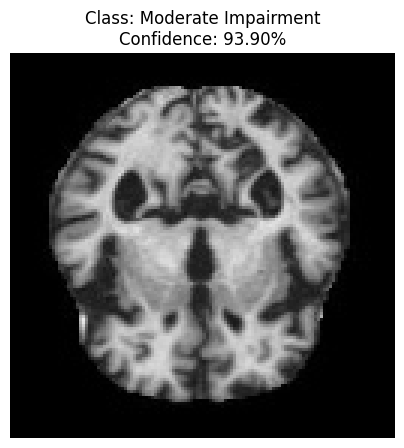

In [20]:
test_path = 'Test The Model/ModerateImpairment (1).jpg'
predict_local_scan(test_path)